In [45]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

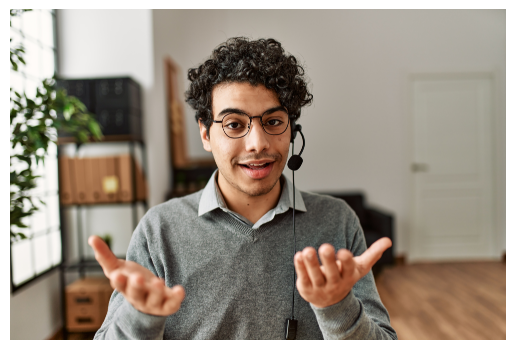

In [46]:
net = cv.dnn.readNetFromCaffe('deploy.prototxt','res10_300x300_ssd_iter_140000_fp16.caffemodel')

img = cv.imread('test.jpg')
#img = cv.cvtColor(img,cv.COLOR_BGR2RGB)

(h,w) = img.shape[:2]

plt.imshow(cv.cvtColor(img,cv.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [47]:
blob = cv.dnn.blobFromImage(cv.resize(img,(300,300)),
                            1.0,
                            (300,300),
                            (104,177,123)
                            )

net.setInput(blob)
detections = net.forward()

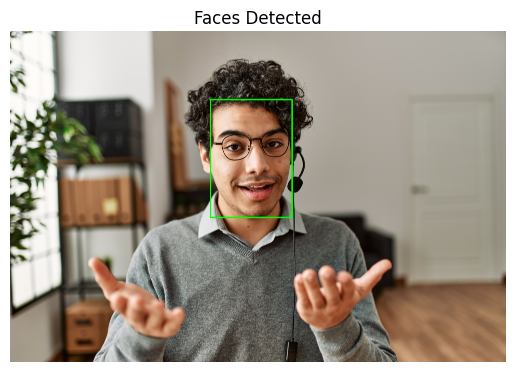

In [53]:
temp = img.copy()
for i in range(detections.shape[2]):
    confidence = detections[0,0,i,2]

    if confidence>.5:
        box = detections[0,0,i,3:7]*np.array([w,h,w,h])
        (x1,y1,x2,y2) = box.astype("int")
        cv.rectangle(temp,(x1,y1),(x2,y2),(0,255,0),25)

plt.imshow(cv.cvtColor(temp,cv.COLOR_BGR2RGB))
plt.title('Faces Detected')
plt.axis('off')
plt.show()

In [63]:
faces = []

pad = 20   # number of pixels to expand

for i in range(detections.shape[2]):

    confidence = detections[0,0,i,2]

    if confidence > 0.7:

        box = detections[0,0,i,3:7] * np.array([w,h,w,h])
        (x1,y1,x2,y2) = box.astype("int")
        #pad = int(0.15 * (x2 - x1))
        # apply padding
        x1 = max(0, x1 - pad)
        y1 = max(0, y1 - pad)
        x2 = min(w, x2 + pad)
        y2 = min(h, y2 + pad)

        # draw padded box
        cv.rectangle(img,(x1,y1),(x2,y2),(0,255,0),2)

        # crop face
        face = img[y1:y2, x1:x2]

        # resize for recognition model
        face = cv.resize(face,(160,160))

        faces.append(face)

(np.float64(-0.5), np.float64(159.5), np.float64(159.5), np.float64(-0.5))

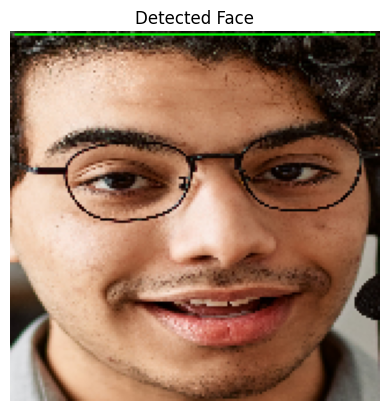

In [64]:
plt.imshow(cv.cvtColor(faces[0],cv.COLOR_BGR2RGB))
plt.title("Detected Face")
plt.axis("off")